## Lecture 4

In this notebook we implement the full GAN training methodology: the Generator, the Maxout activation, the Discriminator, and the training loop, then visualize generated MNIST digits.

In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
device = torch.device('cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='mps')

In [3]:
noise_dim = 100

Generator Model

In [4]:
class Generator(torch.nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=noise_dim,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=1200,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=1200,
                out_features=1200,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            # Fully Connected Layer 4
            torch.nn.Linear(
                in_features=1200,
                out_features=784,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, batch):
        ret = batch.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

Maxout Activation

Source: [https://github.com/pytorch/pytorch/issues/805](https://github.com/pytorch/pytorch/issues/805)

In [5]:
class Maxout(torch.nn.Module):

    def __init__(self, num_pieces):

        super(Maxout, self).__init__()

        self.num_pieces = num_pieces

    def forward(self, x):

        # x.shape = (batch_size? x 625)

        assert x.shape[1] % self.num_pieces == 0  # 625 % 5 = 0

        ret = x.view(
            *x.shape[:1],  # batch_size
            x.shape[1] // self.num_pieces,  # piece-wise linear
            self.num_pieces,  # num_pieces
            *x.shape[2:]  # remaining dimensions if any
        )

        # ret.shape = (batch_size? x 125 x 5)

        # https://pytorch.org/docs/stable/torch.html#torch.max
        ret, _ = ret.max(dim=2)

        # ret.shape = (batch_size? x 125)

        return ret

Discriminator Model

In [6]:
class Discriminator(torch.nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=784,
                out_features=625,
                bias=True
            ),
            Maxout(5),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=125,
                out_features=625,
                bias=True
            ),
            Maxout(5),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=125,
                out_features=1,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, batch):
        ret = batch.view(batch.size(0), -1)
        ret = self.fcn(ret)
        return ret

## Lecture 4

MNIST Dataset

In [7]:
import torchvision

In [8]:
class FlattenTransform:

    def __call__(self, inputs):
        return inputs.view(inputs.shape[0], -1)


data_train = torchvision.datasets.MNIST(
    './data/mnist',
    train=True,
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        FlattenTransform()
    ])
)

In [9]:
BATCH_SIZE = 32

train_loader = torch.utils.data.DataLoader(
    data_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

GAN Training

In [10]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)


discriminator_optimizer = torch.optim.SGD(
    discriminator.parameters(),
    lr=0.0002,
    momentum=0.5
)

generator_optimizer = torch.optim.SGD(
    generator.parameters(),
    lr=0.0002,
    momentum=0.5
)

criterion = torch.nn.BCELoss()

In [11]:
real_labels = torch.ones(BATCH_SIZE, 1).to(device)
fake_labels = torch.zeros(BATCH_SIZE, 1).to(device)

test_set = torch.randn(16, noise_dim).to(device)

num_epochs = 512
num_steps = len(train_loader) // BATCH_SIZE

In [12]:
import os

if not os.path.exists('visuals'):
    os.mkdir('visuals')

In [13]:
for epoch in range(num_epochs):

    for i, (images, _) in enumerate(train_loader):

        if i == num_steps:
            break

        # Train Discriminator
        for _ in range(1):

            real_images = images.to(device)

            fake_images = generator(
                torch.randn(BATCH_SIZE, noise_dim).to(device)
            )

            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images)

            d_x = criterion(real_outputs, real_labels)
            d_g_z = criterion(fake_outputs, fake_labels)

            d_x.backward()
            d_g_z.backward()

            discriminator_optimizer.step()

        # Train Generator
        z = torch.randn(BATCH_SIZE, noise_dim).to(device)

        generator.zero_grad()

        outputs = discriminator(generator(z))

        loss = criterion(outputs, real_labels)

        loss.backward()

        generator_optimizer.step()

    # Visualize Results
    if epoch % 10 == 0:

        generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

        grid = torchvision.utils.save_image(
            generated,
            os.path.join(
                'visuals',
                '{}.jpg'.format(
                    str(epoch).zfill(6)
                )
            ),
            nrow=4,
            padding=10,
            pad_value=1
        )

Visualize the final generated results after training.

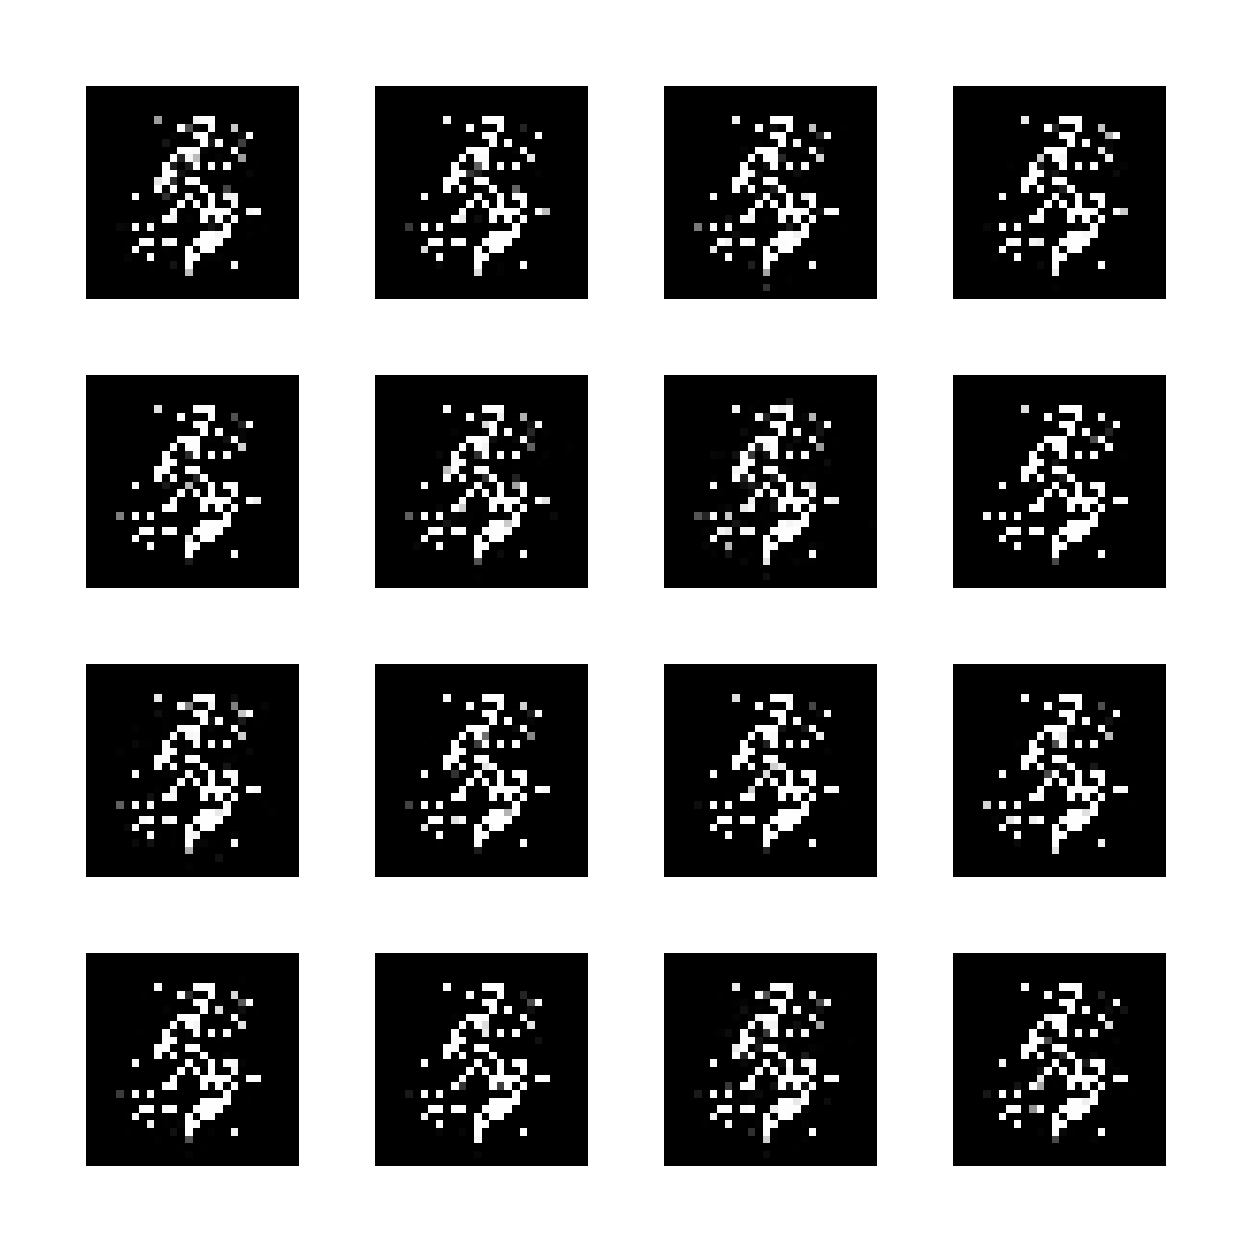

In [14]:
# Visualize Results
generated = generator(test_set).detach().cpu().view(-1, 1, 28, 28)

grid = torchvision.utils.make_grid(
    generated,
    nrow=4,
    padding=10,
    pad_value=1
)

img = np.transpose(
    grid.numpy(),
    (1, 2, 0)
)

fig = plt.figure(figsize=(16, 16))
plt.axis("off")
plt.imshow(img);

Google Collaboratory

Notebook: [https://colab.research.google.com/drive/1ZFvYoDhrLrUwrv-hUpNXJGxndEeRvl8H](https://colab.research.google.com/drive/1ZFvYoDhrLrUwrv-hUpNXJGxndEeRvl8H)

## Evaluation Metrics: Inception Score

Source: [https://sudomake.ai/inception-score-explained/](https://sudomake.ai/inception-score-explained/)

In [15]:
import math
import torch.nn.functional as F
from torchvision.models import inception_v3, Inception_V3_Weights


# initialize pretrained inception network
net = inception_v3(weights=Inception_V3_Weights.DEFAULT).to(device)
net.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (con

The `inception_score` function below batches the given `images` through the pretrained Inception v3 network, then computes the Inception Score as the mean KL divergence between each image's predicted class distribution `p(y|x)` and the marginal class distribution `p(y)` across all generated images.

Each mini-batch is passed through the inception network. That is one row for each image, and averaging the score over these groups gives the final estimate.

**Adaptations from the original course code** (so it runs on a modern PyTorch/torchvision install):
- `from torch.autograd import Variable` and `batch = Variable(mini_batch)` are removed -- modern PyTorch tensors track gradients natively, `Variable` has been a no-op wrapper for years.
- `inception_v3(pretrained=True)` is replaced with `inception_v3(weights=Inception_V3_Weights.DEFAULT)`, since the `pretrained` argument is deprecated.
- `net.eval()` is called once when the network is created. In eval mode, `torchvision`'s Inception v3 returns a single logits tensor (not the `(logits, aux_logits)` tuple it returns in training mode), so the forward pass below is `s = net(batch)` rather than `s, _ = net(batch)` -- unpacking a plain tensor as `s, _ = net(batch)` would raise a `TypeError` in eval mode. The course video's comment about "skipping aux logits" still applies conceptually: we only ever use the primary output.
- The forward pass runs inside `torch.no_grad()` since we're only scoring images, not training the inception network.

In [16]:
def inception_score(images, batch_size):

    # list of scores
    scores = []

    # number of steps
    num_steps = int(math.ceil(float(len(images)) / float(batch_size)))

    # iterate over the images
    for i in range(num_steps):

        # mini-batch start and end index
        s = i * batch_size
        e = (i + 1) * batch_size

        # mini-batch images
        mini_batch = images[s:e]

        # mini-batch as Torch tensor with gradients
        batch = mini_batch

        # apply a forward pass through inception network
        # skipping aux logits
        '''
        This network is unique because it has two output layers when training.
        The second output is known as an auxiliary output and is contained
        only when the model is in training mode.
        The primary output is a linear layer at the end of the network.
        Note, when testing we only consider the primary output.
        '''
        with torch.no_grad():
            s = net(batch)

        # accumulate scores
        scores.append(s)

    # stack scores as tensor
    scores = torch.cat(scores, 0)

    # calculate inception score

    '''
    The formula for inception score
    IS(x) = E[ KL( P(y|x) || P(y)) ]
    x: generated images
    y: inception model classification distribution aka softmax
    '''

    # calculate p(y|x) across dimension 1
    # that is one row for each image
    p_yx = F.softmax(scores, 1)

    # calculate p(y) across dimension 0
    # that is one column for each class / label
    p_y = p_yx.mean(0).unsqueeze(0).expand(p_yx.size(0), -1)

    # calculate KL divergence
    KL_d = p_yx * (torch.log(p_yx) - torch.log(p_y))

    # calculate mean aka expected of KL
    final_score = KL_d.mean()

    # return final score
    return final_score

In [17]:
# test inception score on generated images

# generate images
images = generator(test_set)

# reshape to 1x28x28
images = images.view(-1, 1, 28, 28)

# repeat Gray channel to RGB
images = images.repeat(1, 3, 1, 1)

# resize the images to 3x299x299
res_images = F.interpolate(images, size=(299, 299))

# calculate inception score
score = inception_score(res_images, BATCH_SIZE)

# get value from tensor variable
score.item()

1.1999271919194143e-05

You need to have an objective metric, and then, if you scroll down, you'll find that we try the same experiment over a batch of real images from the original dataset -- as a sanity check / comparison point for the generated-image score above.

That's one of the caveats of this metric: since it was designed for natural images from a 1000-class ImageNet-trained network, the absolute magnitude of Inception Score on MNIST digits (a 10-class, grayscale dataset) is not very meaningful on its own -- it is mainly useful for *relative* comparison between generators, or between generated vs. real images from the same dataset, as done here.

In [18]:
# test inception score on real images

# load mini batch from dataset
images, _ = next(iter(train_loader))

# convert to GPU
images = images.to(device)

# reshape to 1x28x28
images = images.view(-1, 1, 28, 28)

# repeat Gray channel to RGB
images = images.repeat(1, 3, 1, 1)

# resize the images to 3x299x299
res_images = F.interpolate(images, size=(299, 299))

# calculate inception score
score = inception_score(res_images, BATCH_SIZE)

# get value from tensor variable
score.item()

0.0006808178150095046

I hope that gives you an idea about the complexity of evaluating generative models, and about the nobility -- and limitations -- of metrics like Inception Score.

## Reading Assignment

- Tim Salimans, Ian Goodfellow, Wojciech Zaremba, Vicki Cheung, Alec Radford, Xi Chen. 2016. **Improved Techniques for Training GANs.**